In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from src.data_loader import load_raw_data
from src.preprocessing import create_train_test_split, scale_features
from src.evaluate_model import print_model_report
from src.config import TARGET_COLUMN

In [2]:
df = load_raw_data()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X_train, X_test, y_train, y_test = create_train_test_split(df)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("y_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train distribution:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64
y_test distribution:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [4]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

X_train_scaled[["Time", "Amount"]].describe()

,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.409578e-16,3.742243e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


In [5]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [6]:
y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

In [7]:
baseline_metrics = print_model_report(y_test, y_pred, y_proba)

Model Evaluation Metrics
------------------------
Accuracy:  0.9755
Precision: 0.0610
Recall:    0.9184
F1-score:  0.1144
ROC-AUC:   0.9722

Confusion Matrix:
[[55478  1386]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



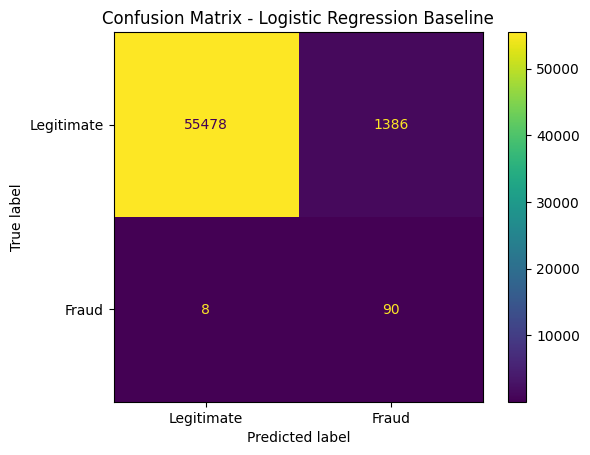

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.show()

## Baseline Model Results

The Logistic Regression baseline achieved high recall, catching 90 out of 98 fraudulent transactions in the test set. However, precision was low because the model incorrectly flagged 1,386 legitimate transactions as fraud.

This indicates that the baseline model is effective at identifying potential fraud, but it produces many false positives. In a real financial setting, this could create unnecessary manual reviews or customer friction. Because of this tradeoff, threshold tuning will be important before using the model for business decisions such as approve, deny, or manual review.

The ROC-AUC score of 0.9722 suggests that the model is strong at ranking fraudulent transactions above legitimate ones, even though the default classification threshold needs improvement.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1_score,false_positives,false_negatives,true_positives,true_negatives
0,0.1,0.008117,0.948980,0.016097,11364,5,93,45500
1,0.2,0.016358,0.938776,0.032157,5532,6,92,51332
2,0.3,0.027298,0.918367,0.053019,3207,8,90,53657
3,0.4,0.042056,0.918367,0.080429,2050,8,90,54814
4,0.5,0.060976,0.918367,0.114358,1386,8,90,55478
5,0.6,0.086660,0.908163,0.158222,938,9,89,55926
6,0.7,0.121419,0.908163,0.214200,644,9,89,56220
7,0.8,0.160878,0.897959,0.272868,459,10,88,56405
8,0.9,0.245070,0.887755,0.384106,268,11,87,56596


## Threshold Analysis

I evaluated multiple classification thresholds to understand the tradeoff between precision, recall, false positives, and false negatives.

Lower thresholds catch more fraud but create many false positives, which could increase manual review workload and customer friction. Higher thresholds reduce false positives but may miss more fraudulent transactions.

For the baseline Logistic Regression model, a threshold around 0.8 provides a more practical balance than the default 0.5 threshold. It reduces false positives from 1,386 to 459 while only reducing true positives from 90 to 88.

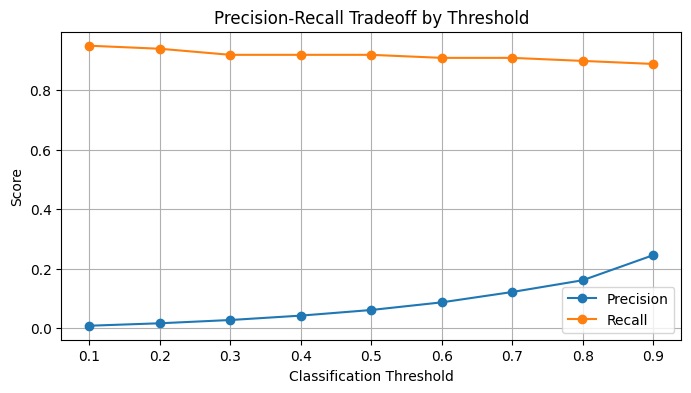

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff by Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def make_business_recommendation(probability):
    """
    Convert fraud probability into a business recommendation.
    """
    if probability >= 0.80:
        return "Deny"
    elif probability >= 0.30:
        return "Manual Review"
    else:
        return "Approve"

In [13]:
recommendations = pd.DataFrame({
    "fraud_probability": y_proba,
    "actual_class": y_test.values
})

recommendations["recommendation"] = recommendations["fraud_probability"].apply(
    make_business_recommendation
)

recommendations.head(10)

,fraud_probability,actual_class,recommendation
0,0.005842,0,Approve
1,0.069181,0,Approve
2,0.000134,0,Approve
3,0.015159,0,Approve
4,0.945210,0,Deny
5,0.013883,0,Approve
6,0.000866,0,Approve
7,0.027084,0,Approve
8,0.066034,0,Approve
9,0.004585,0,Approve


In [14]:
recommendations["recommendation"].value_counts()

recommendation
Approve          53665
Manual Review     2750
Deny               547
Name: count, dtype: int64

In [15]:
recommendation_summary = recommendations.groupby("recommendation").agg(
    total_transactions=("actual_class", "count"),
    fraud_transactions=("actual_class", "sum"),
    fraud_rate=("actual_class", "mean"),
    avg_fraud_probability=("fraud_probability", "mean")
)

recommendation_summary["fraud_rate_percent"] = recommendation_summary["fraud_rate"] * 100

recommendation_summary

,total_transactions,fraud_transactions,fraud_rate,avg_fraud_probability,fraud_rate_percent
recommendation,,,,,
Approve,53665,8,0.000149,0.047069,0.014907
Deny,547,88,0.160878,0.926410,16.087751
Manual Review,2750,2,0.000727,0.461513,0.072727


In [16]:
import joblib

from src.config import MODEL_DIR

MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "logistic_regression_baseline.joblib"
scaler_path = MODEL_DIR / "standard_scaler.joblib"

joblib.dump(baseline_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: C:\Users\shard\Desktop\credit-risk-fraud-detection\models\logistic_regression_baseline.joblib
Scaler saved to: C:\Users\shard\Desktop\credit-risk-fraud-detection\models\standard_scaler.joblib


In [17]:
import importlib
import src.predict
importlib.reload(src.predict)

from src.predict import predict_transaction_risk

In [18]:
from src.predict import predict_transaction_risk

sample_transaction = X_test.iloc[[0]]

risk_result = predict_transaction_risk(sample_transaction)

risk_result

{'fraud_probability': 0.005842174994496537,
 'risk_band': 'Low Risk',
 'recommendation': 'Approve'}

In [19]:
high_risk_position = recommendations["fraud_probability"].values.argmax()

sample_high_risk_transaction = X_test.iloc[[high_risk_position]]

high_risk_result = predict_transaction_risk(sample_high_risk_transaction)

high_risk_result

{'fraud_probability': 1.0, 'risk_band': 'High Risk', 'recommendation': 'Deny'}

In [20]:
from src.agents.risk_scoring_agent import RiskScoringAgent

risk_agent = RiskScoringAgent()

risk_agent_result = risk_agent.score_transaction(sample_transaction)

risk_agent_result

{'agent_name': 'Risk Scoring Agent',
 'fraud_probability': 0.005842174994496537,
 'risk_band': 'Low Risk',
 'recommendation': 'Approve'}

In [21]:
risk_agent_high_risk_result = risk_agent.score_transaction(sample_high_risk_transaction)

risk_agent_high_risk_result

{'agent_name': 'Risk Scoring Agent',
 'fraud_probability': 1.0,
 'risk_band': 'High Risk',
 'recommendation': 'Deny'}

In [22]:
from src.agents.investigation_agent import InvestigationAgent

investigation_agent = InvestigationAgent()

low_risk_investigation = investigation_agent.investigate(risk_agent_result)

print(low_risk_investigation["investigation_summary"])


Transaction Risk Investigation Summary

Fraud Probability: 0.0058
Risk Band: Low Risk
Initial Recommendation: Approve

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as low risk because its fraud probability is below the manual review threshold of 0.30. Based on the current model score, the transaction does not show enough risk to require escalation, so it can be approved while continuing standard fraud monitoring.

Suggested Action:
Approve the transaction and continue standard monitoring.



In [23]:
high_risk_investigation = investigation_agent.investigate(risk_agent_high_risk_result)

print(high_risk_investigation["investigation_summary"])


Transaction Risk Investigation Summary

Fraud Probability: 1.0000
Risk Band: High Risk
Initial Recommendation: Deny

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as high risk because its fraud probability exceeds the denial threshold of 0.80. The model uses anonymized transaction signals such as V17, V14, V12, and V10, which showed strong statistical separation between fraudulent and legitimate transactions during exploratory analysis. Because the score is in the high-risk band, the transaction should not be automatically approved.

Suggested Action:
Deny the transaction and escalate the case to fraud operations for review.



In [24]:
from src.agents.policy_agent import PolicyAgent

policy_agent = PolicyAgent()

low_risk_policy_review = policy_agent.review_policy(risk_agent_result)

print(low_risk_policy_review["policy_guidance"])

Relevant Policy: Low Risk

Transactions with fraud probability below 0.30 are considered low risk. The recommended action is to approve the transaction and continue standard monitoring.


In [25]:
high_risk_policy_review = policy_agent.review_policy(risk_agent_high_risk_result)

print(high_risk_policy_review["policy_guidance"])

Relevant Policy: High Risk

Transactions with fraud probability greater than or equal to 0.80 are considered high risk. The recommended action is to deny the transaction and escalate the case to fraud operations.


In [26]:
from src.agents.decision_agent import DecisionAgent

decision_agent = DecisionAgent()

low_risk_decision = decision_agent.create_final_decision(
    risk_result=risk_agent_result,
    investigation_result=low_risk_investigation,
    policy_result=low_risk_policy_review
)

print(low_risk_decision["final_report"])


Final Fraud Risk Decision Report

Final Recommendation: Approve
Risk Band: Low Risk
Fraud Probability: 0.0058

Business Action:
Approve the transaction and continue standard monitoring.

Policy Support:
Relevant Policy: Low Risk

Transactions with fraud probability below 0.30 are considered low risk. The recommended action is to approve the transaction and continue standard monitoring.

Investigation Summary:

Transaction Risk Investigation Summary

Fraud Probability: 0.0058
Risk Band: Low Risk
Initial Recommendation: Approve

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as low risk because its fraud probability is below the manual review threshold of 0.30. Based on the current model score, the transaction does not show enough risk to require escalation, so it can be approved while continuing standard fraud monitoring.

Suggested Action:
Approve the transaction and continue standard monitoring.




In [27]:
high_risk_decision = decision_agent.create_final_decision(
    risk_result=risk_agent_high_risk_result,
    investigation_result=high_risk_investigation,
    policy_result=high_risk_policy_review
)

print(high_risk_decision["final_report"])


Final Fraud Risk Decision Report

Final Recommendation: Deny
Risk Band: High Risk
Fraud Probability: 1.0000

Business Action:
Deny the transaction and escalate the case to fraud operations for review.

Policy Support:
Relevant Policy: High Risk

Transactions with fraud probability greater than or equal to 0.80 are considered high risk. The recommended action is to deny the transaction and escalate the case to fraud operations.

Investigation Summary:

Transaction Risk Investigation Summary

Fraud Probability: 1.0000
Risk Band: High Risk
Initial Recommendation: Deny

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as high risk because its fraud probability exceeds the denial threshold of 0.80. The model uses anonymized transaction signals such as V17, V14, V12, and V10, which showed strong statistical separation between fraudulent and legitimate transactions during exploratory analysis. Because the score is in the high-risk band, the

In [28]:
from src.agents.fraud_decision_workflow import run_fraud_decision_workflow

low_risk_workflow_result = run_fraud_decision_workflow(sample_transaction)

print(low_risk_workflow_result["final_report"])


Final Fraud Risk Decision Report

Final Recommendation: Approve
Risk Band: Low Risk
Fraud Probability: 0.0058

Business Action:
Approve the transaction and continue standard monitoring.

Policy Support:
Relevant Policy: Low Risk

Transactions with fraud probability below 0.30 are considered low risk. The recommended action is to approve the transaction and continue standard monitoring.

Investigation Summary:

Transaction Risk Investigation Summary

Fraud Probability: 0.0058
Risk Band: Low Risk
Initial Recommendation: Approve

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as low risk because its fraud probability is below the manual review threshold of 0.30. Based on the current model score, the transaction does not show enough risk to require escalation, so it can be approved while continuing standard fraud monitoring.

Suggested Action:
Approve the transaction and continue standard monitoring.




In [29]:
high_risk_workflow_result = run_fraud_decision_workflow(sample_high_risk_transaction)

print(high_risk_workflow_result["final_report"])


Final Fraud Risk Decision Report

Final Recommendation: Deny
Risk Band: High Risk
Fraud Probability: 1.0000

Business Action:
Deny the transaction and escalate the case to fraud operations for review.

Policy Support:
Relevant Policy: High Risk

Transactions with fraud probability greater than or equal to 0.80 are considered high risk. The recommended action is to deny the transaction and escalate the case to fraud operations.

Investigation Summary:

Transaction Risk Investigation Summary

Fraud Probability: 1.0000
Risk Band: High Risk
Initial Recommendation: Deny

Key Risk Signals:
- V17
- V14
- V12
- V10
- V16
- V3
- V7

Analysis:
This transaction was classified as high risk because its fraud probability exceeds the denial threshold of 0.80. The model uses anonymized transaction signals such as V17, V14, V12, and V10, which showed strong statistical separation between fraudulent and legitimate transactions during exploratory analysis. Because the score is in the high-risk band, the